In [1]:
!pip install arch
# -r ../requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import glob
import os

In [3]:
df = pd.read_csv("../Data_clean/ETF clean/spy_clean.csv", index_col=0, parse_dates=True)
df.sort_index(ascending=True, inplace=True)
returns_df = df.drop(columns=['Open', 'High', 'Low']).pct_change().apply(lambda x: np.log(1 + x))

c:\Users\bartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
returns_df.head()

,Close,Volume
Date,,
2005-02-25,NaN,NaN
2005-02-28,-0.006734,0.126552
2005-03-01,0.005126,-0.378042
2005-03-02,-0.000474,0.300282
2005-03-03,0.000379,-0.033740


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# 1. reading SPY data
# Date,Open,High,Low,Close,Volume
spy_path = '../Data_clean/ETF clean/spy_clean.csv'
df_spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
df_spy.sort_index(ascending=True, inplace=True)

df_spy['Returns'] = np.log(df_spy['Close'] / df_spy['Close'].shift(1))
df_spy.dropna(inplace=True)

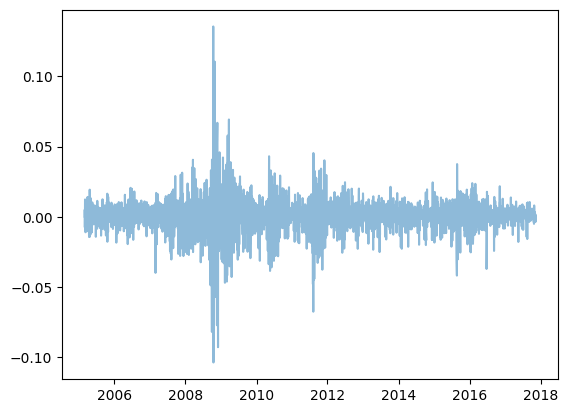

In [6]:
plt.plot(df_spy.index, df_spy['Returns'], alpha=0.5)


Text(0.5, 0, 'h')

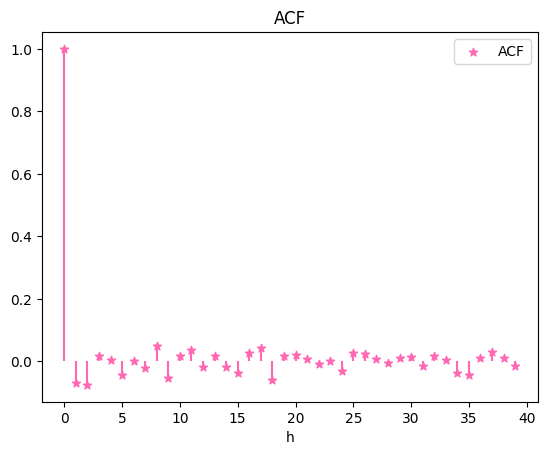

In [7]:
def sampleACVF(X, h):
    n = len(X)
    x_mean = np.mean(X)
    return 1/n*sum((X[i]-x_mean)*(X[i+abs(h)]-x_mean) for i in range(1,n-abs(h)))
def sampleACF(X, h):
    return sampleACVF(X, h)/sampleACVF(X, 0)

hs = np.arange(40)
acc = [sampleACF(np.array(df_spy['Returns']), h) for h in hs]
plt.vlines(x=hs, ymin=0, ymax=acc, color = 'hotpink')
plt.scatter(hs, acc, marker = '*', color = 'hotpink', label = 'ACF')
plt.title('ACF'); plt.legend()
plt.xlabel('h')

Text(0.5, 0, 'h')

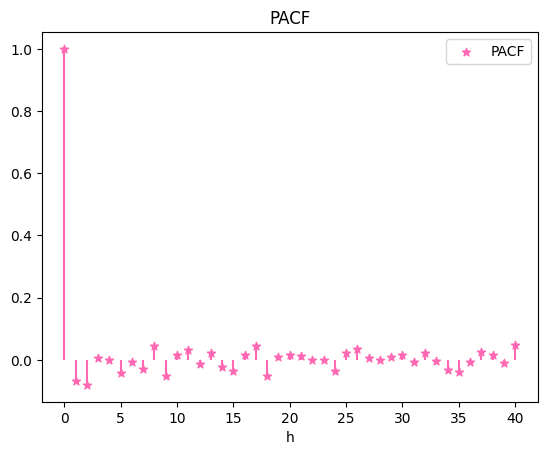

In [8]:
from statsmodels.tsa.stattools import pacf, adfuller, acf
pacf_, confint = pacf(np.array(df_spy['Returns']), nlags=40, method='ld', alpha=0.05)
# c1, c2 = np.array([p[0] for p in confint]), np.array([p[1] for p in confint])
# plt.fill_between(hs1, c1, c2, color = 'darkseagreen')
hs1 = np.arange(41)
plt.vlines(x=hs1, ymin=0, ymax=pacf_, color = 'hotpink')
plt.scatter(hs1, pacf_, marker = '*', color = 'hotpink', label = 'PACF')
plt.title('PACF'); plt.legend()
plt.xlabel('h')

In [9]:
data = df_spy['Returns'].values

df = pd.DataFrame()
ps = []
qs = []
BIC = []
AIC = []
HQIC = []

max_p = 5
max_q = 5

for p in range(0, max_p):
    for q in range(0, max_q):
        model = ARIMA(data, order=(p, 0, q))
        model_fit = model.fit()
        ps.append(p)
        qs.append(q)
        AIC.append(model_fit.aic)
        BIC.append(model_fit.bic)
        HQIC.append(model_fit.hqic)

df['p']    = ps
df['q']    = qs
df['AIC']  = AIC
df['BIC']  = BIC
df['HQIC'] = HQIC

In [10]:
df.sort_values(by='AIC').head()

,p,q,AIC,BIC,HQIC
19,3,4,-20148.781009,-20093.825093,-20129.113654
9,1,4,-20144.688293,-20101.944803,-20129.391462
10,2,0,-20144.408184,-20119.983333,-20135.667138
2,0,2,-20144.018746,-20119.593894,-20135.277699
15,3,0,-20142.470152,-20111.939088,-20131.543845


In [11]:
df.sort_values(by='BIC').head()

,p,q,AIC,BIC,HQIC
10,2,0,-20144.408184,-20119.983333,-20135.667138
2,0,2,-20144.018746,-20119.593894,-20135.277699
6,1,1,-20136.381907,-20111.957055,-20127.640860
15,3,0,-20142.470152,-20111.939088,-20131.543845
11,2,1,-20142.467797,-20111.936732,-20131.541489


In [12]:
df.sort_values(by='HQIC').head()

,p,q,AIC,BIC,HQIC
10,2,0,-20144.408184,-20119.983333,-20135.667138
2,0,2,-20144.018746,-20119.593894,-20135.277699
15,3,0,-20142.470152,-20111.939088,-20131.543845
11,2,1,-20142.467797,-20111.936732,-20131.541489
3,0,3,-20142.129467,-20111.598403,-20131.203159


In [13]:
# 2. stationarity test (ADF Test)
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] < 0.05

print("--- SPY Stationarity Test ---")
is_stationary = check_stationarity(df_spy['Returns'])
print(f"Stationary? {is_stationary}\n")

--- SPY Stationarity Test ---
ADF Statistic: -14.1793
p-value: 0.0000
Stationary? True



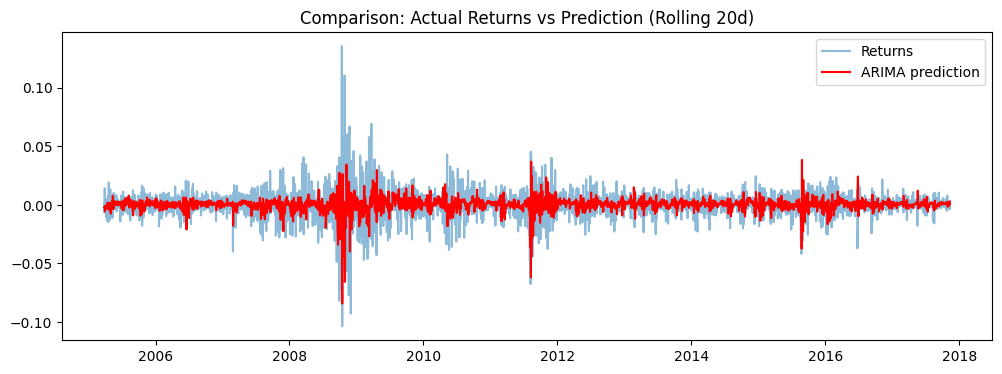

In [14]:
window = 20
results = []

for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # ARIMA(1,0,1) - d=0 logreturns are already stationary
    model = ARIMA(train_window, order=(2, 0, 0)).fit()
    forecast = model.forecast(steps=1).values[0]
    results.append(forecast)

# results DF (omit first 20 days)
df_eval = df_spy.iloc[window:].copy()
df_eval['Pred_Return'] = results

# comparison plot - last 100 days for readability
plt.figure(figsize=(12, 4))
plt.plot(df_eval['Returns'], label='Returns', alpha=0.5)
plt.plot(df_eval['Pred_Return'], label='ARIMA prediction', color='red')
plt.title('Comparison: Actual Returns vs Prediction (Rolling 20d)')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error

mae_returns = mean_absolute_error(df_eval['Returns'], df_eval['Pred_Return'])
print(f"MAE (Returns, ARIMA rolling 20d): {mae_returns:.6f}")

MAE (Returns, ARIMA rolling 20d): 0.007939


In [16]:
# SPY test
model_test = ARIMA(df_spy['Returns'].tail(100), order=(2, 0, 0)).fit()
print(model_test.summary())

                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  100
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 409.318
Date:                Mon, 04 May 2026   AIC                           -810.636
Time:                        15:19:48   BIC                           -800.216
Sample:                    06-26-2017   HQIC                          -806.419
                         - 11-10-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.698      0.090      -0.000       0.001
ar.L1         -0.1670      0.111     -1.506      0.132      -0.384       0.050
ar.L2         -0.0956      0.107     -0.896      0.3

In [17]:
from sklearn.metrics import accuracy_score

df_eval['Actual_Dir'] = np.where(df_eval['Returns'] > 0, 1, 0)
df_eval['Pred_Dir'] = np.where(df_eval['Pred_Return'] > 0, 1, 0)

acc = accuracy_score(df_eval['Actual_Dir'], df_eval['Pred_Dir'])

print(f"Accuracy (Up/down?): {acc:.2%}")

Accuracy (Up/down?): 51.02%


C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\1697982001.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\1697982001.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\1697982001.py:7: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykerne

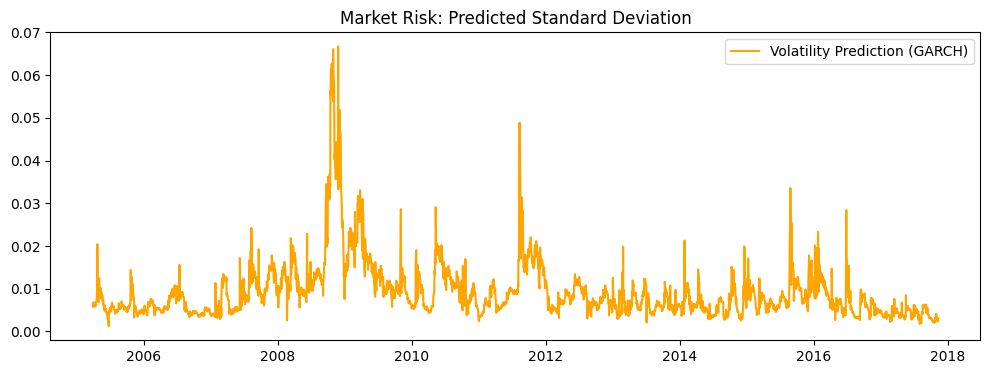

In [18]:
# GARCH window 20
vols = []

for i in range(len(df_spy) - window):
    train_window = df_spy['Returns'].iloc[i:i+window]
    # rescale=False, to keep units of returns
    garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
    v_forecast = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
    vols.append(v_forecast)

df_eval['Pred_Vol'] = vols

# Volatility plot
plt.figure(figsize=(12, 4))
plt.plot(df_eval['Pred_Vol'], color='orange', label='Volatility Prediction (GARCH)')
plt.title('Market Risk: Predicted Standard Deviation')
plt.legend()
plt.show()

Calculating forecasts (Rolling Window 20d)...


C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\4244119901.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\4244119901.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\4244119901.py:35: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipyke

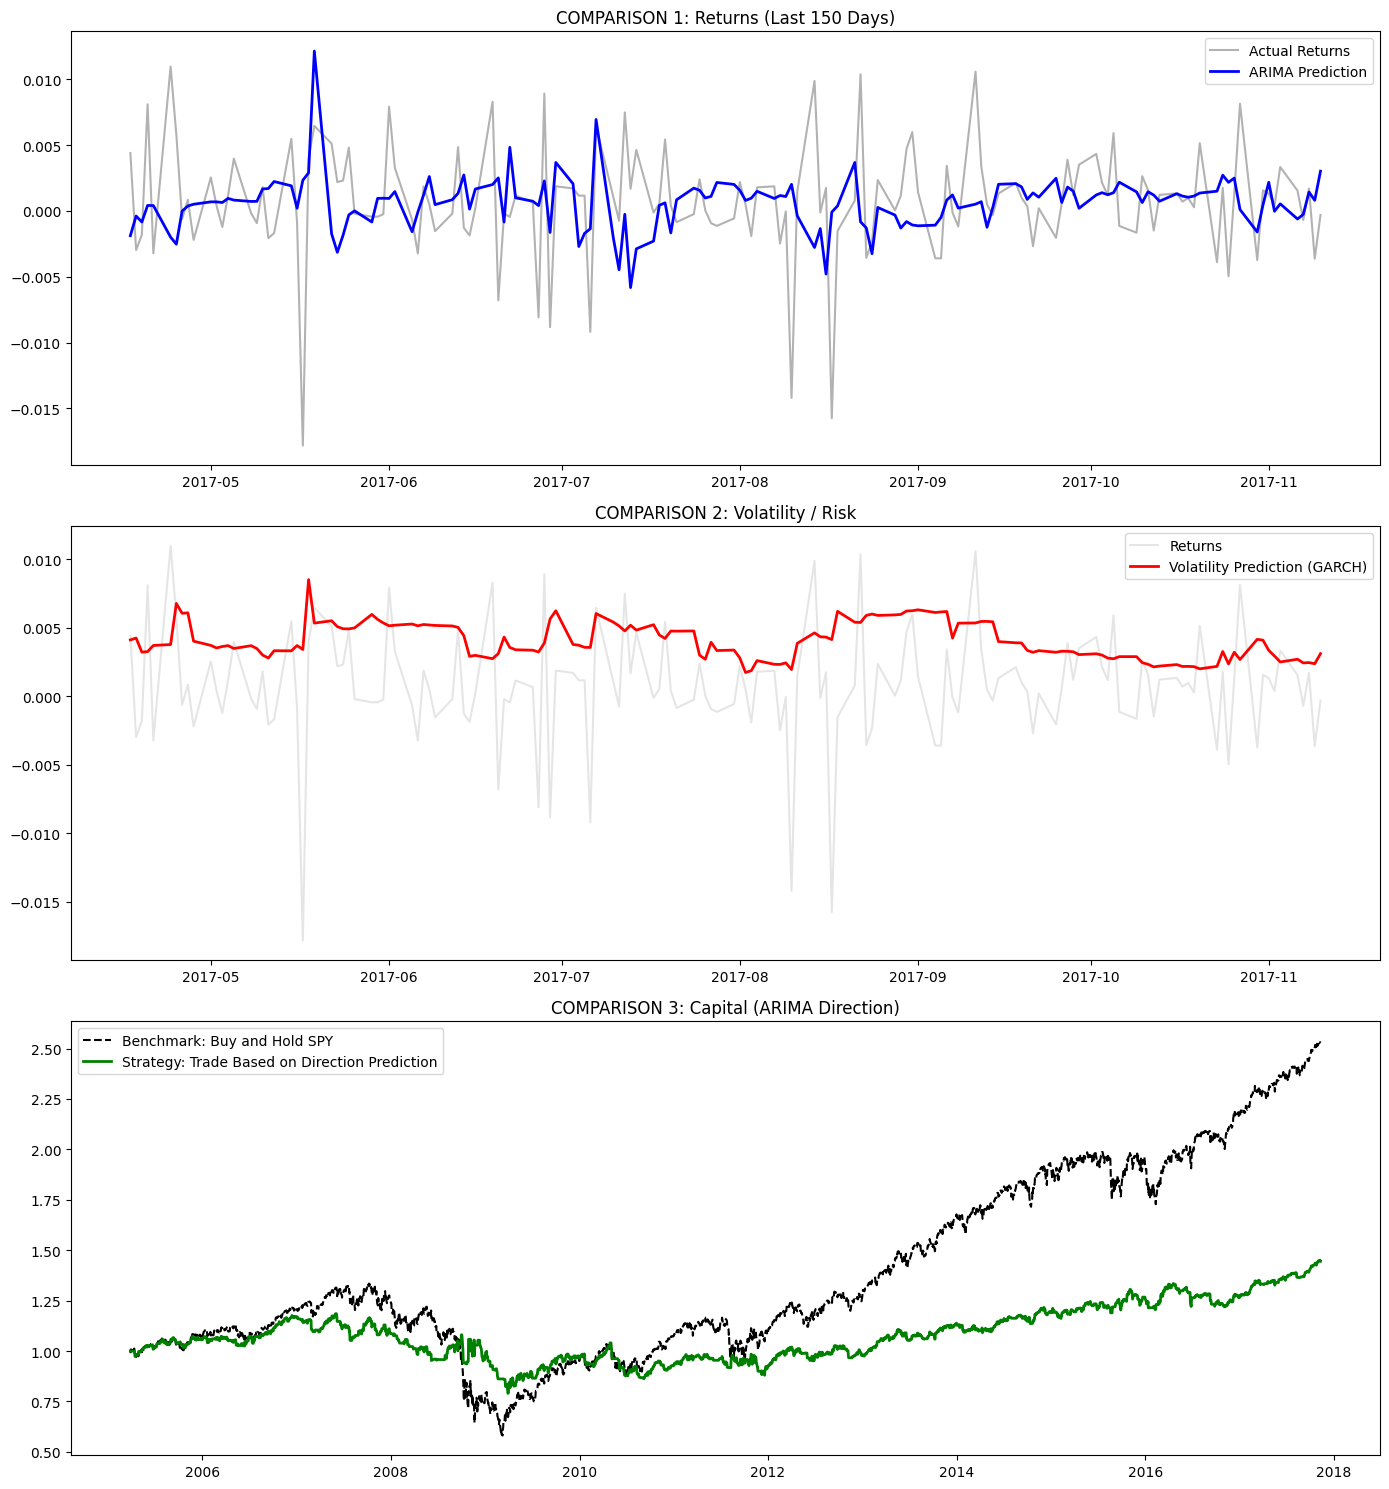

------------------------------
SUMMARY OF SP500 MODEL:
Direction Accuracy: 51.02%
------------------------------
Classification Report:
              precision    recall  f1-score   support

        DOWN       0.45      0.39      0.42      1492
          UP       0.55      0.61      0.58      1803

    accuracy                           0.51      3295
   macro avg       0.50      0.50      0.50      3295
weighted avg       0.50      0.51      0.51      3295

MAE (Returns, ARIMA pełna analiza): 0.007939


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from sklearn.metrics import accuracy_score, classification_report

# 1. data preparation
spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
spy.sort_index(ascending=True, inplace=True)
spy['Returns'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy.dropna(inplace=True)

# Window settings
window = 20
pred_returns = []
pred_vols = []

print("Calculating forecasts (Rolling Window 20d)...")

for i in range(len(spy) - window):
    train_window = spy['Returns'].iloc[i:i+window]
    
    # --- MODEL 1: ARIMA (Returns) ---
    # params: (2,0,0) 
    try:
        arima = ARIMA(train_window, order=(2, 0, 0)).fit()
        f_ret = arima.forecast(steps=1).values[0]
    except: f_ret = 0
        
    # --- MODEL 2: GARCH (Volatility) ---
    # params: (1,1) - standard model
    try:
        garch = arch_model(train_window, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        f_vol = np.sqrt(garch.forecast(horizon=1).variance.values[-1][0])
    except: f_vol = spy['Returns'].std()

    pred_returns.append(f_ret)
    pred_vols.append(f_vol)

# comparison DataFrame
df_comp = spy.iloc[window:].copy()
df_comp['Pred_Return'] = pred_returns
df_comp['Pred_Vol'] = pred_vols
df_comp['Actual_Dir'] = (df_comp['Returns'] > 0).astype(int)
df_comp['Pred_Dir'] = (df_comp['Pred_Return'] > 0).astype(int)
spy_cum = (1 + (np.exp(df_comp['Returns']) - 1)).cumprod()
# --- COMPARATIVE ANALYSIS ---

fig, axs = plt.subplots(3, 1, figsize=(14, 15))

# 1. Comparison of Returns (Regression)
axs[0].plot(df_comp['Returns'].tail(150), label='Actual Returns', color='black', alpha=0.3)
axs[0].plot(df_comp['Pred_Return'].tail(150), label='ARIMA Prediction', color='blue', linewidth=2)
axs[0].set_title('COMPARISON 1: Returns (Last 150 Days)')
axs[0].legend()

# 2. Comparison of Volatility (Risk)
axs[1].plot(df_comp.index[-150:], df_comp['Returns'].tail(150), color='gray', alpha=0.2, label='Returns')
axs[1].plot(df_comp['Pred_Vol'].tail(150), label='Volatility Prediction (GARCH)', color='red', linewidth=2)
axs[1].set_title('COMPARISON 2: Volatility / Risk')
axs[1].legend()

# 3. Cumulative Return (Portfolio Effectiveness)
spy_cum = (1 + (np.exp(df_comp['Returns']) - 1)).cumprod()
strat_cum = (1 + (df_comp['Pred_Dir'] * (np.exp(df_comp['Returns']) - 1))).cumprod()
axs[2].plot(spy_cum, label='Benchmark: Buy and Hold SPY', color='black', linestyle='--')
axs[2].plot(strat_cum, label='Strategy: Trade Based on Direction Prediction', color='green', linewidth=2)
axs[2].set_title('COMPARISON 3: Capital (ARIMA Direction)')
axs[2].legend()

plt.tight_layout()
plt.show()

# --- STATISTICAL SUMMARY ---
acc = accuracy_score(df_comp['Actual_Dir'], df_comp['Pred_Dir'])
print("-" * 30)
print(f"SUMMARY OF SP500 MODEL:")
print(f"Direction Accuracy: {acc:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(df_comp['Actual_Dir'], df_comp['Pred_Dir'], target_names=['DOWN', 'UP']))

from sklearn.metrics import mean_absolute_error

mae_comp = mean_absolute_error(df_comp['Returns'], df_comp['Pred_Return'])
print(f"MAE (Returns, ARIMA pełna analiza): {mae_comp:.6f}")

Generuję zaawansowane cechy (ARIMA 20d, GARCH 60d)...


C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\1746115086.py:40: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\1746115086.py:40: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykernel_7836\1746115086.py:40: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
C:\Users\bartik\AppData\Local\Temp\ipykern


Gotowy Feature Matrix dla modeli ML:
             Close  Dist_From_MA200  ARIMA_20d_Pred  GARCH_60d_Vol
Date                                                              
2017-11-06  258.85         0.073360       -0.000942       0.003510
2017-11-07  258.67         0.071850       -0.000329       0.003716
2017-11-08  259.11         0.072903        0.000815       0.003468
2017-11-09  258.17         0.068267        0.000388       0.002640
2017-11-10  258.09         0.067230        0.003171       0.003149


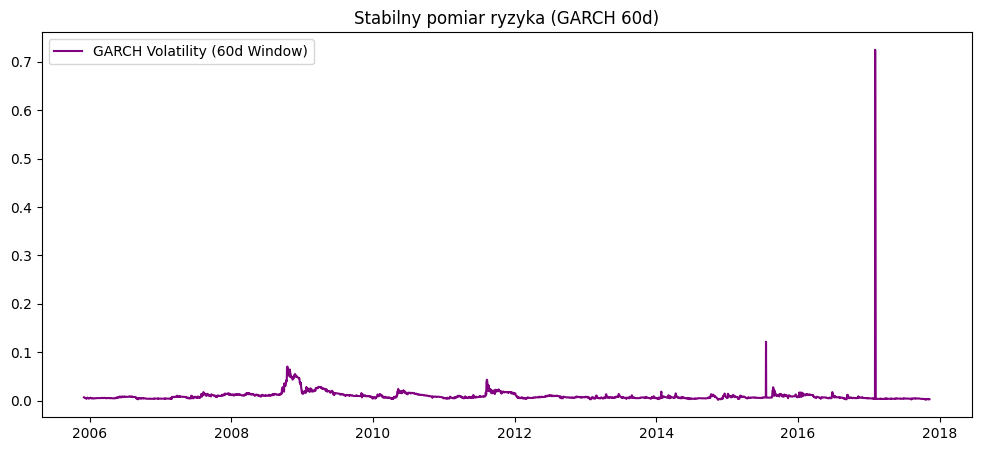

In [20]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")

# 1. Przygotowanie danych bazowych
spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True)
spy.sort_index(ascending=True, inplace=True)
spy['Returns'] = np.log(spy['Close'] / spy['Close'].shift(1))

# 2. Wskaźniki Długoterminowe (Obliczane na całym szeregu - szybkie)
# Średnia krocząca 200 dni (Trend długoterminowy)
spy['MA200_Trend'] = spy['Close'].rolling(window=200).mean()
spy['Dist_From_MA200'] = (spy['Close'] - spy['MA200_Trend']) / spy['MA200_Trend']

# 3. Pętla Krocząca dla ARIMA (20d) i GARCH (60d)
# Zaczynamy od 200, żeby MA200 było już gotowe
start_idx = 200
arima_preds = []
garch_vols = []
dates = []

print("Generuję zaawansowane cechy (ARIMA 20d, GARCH 60d)...")

for i in range(start_idx, len(spy)):
    # --- KRÓTKIE OKNO (20d) dla ARIMA ---
    window_20 = spy['Returns'].iloc[i-20:i]
    try:
        model_arima = ARIMA(window_20, order=(1, 0, 1)).fit()
        pred_ret = model_arima.forecast(steps=1).values[0]
    except: pred_ret = 0
    
    # --- DŁUŻSZE OKNO (60d) dla GARCH ---
    # Zmienność potrzebuje więcej danych, by "zauważyć" trend strachu
    window_60 = spy['Returns'].iloc[i-60:i]
    try:
        model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        pred_vol = np.sqrt(model_garch.forecast(horizon=1).variance.values[-1][0])
    except: pred_vol = spy['Returns'].iloc[:i].std()

    arima_preds.append(pred_ret)
    garch_vols.append(pred_vol)
    dates.append(spy.index[i])

# 4. Łączenie wszystkiego w jedną tabelę (Feature Matrix)
df_features = spy.loc[dates].copy()
df_features['ARIMA_20d_Pred'] = arima_preds
df_features['GARCH_60d_Vol'] = garch_vols

# Czyścimy NaN (z MA200)
df_features.dropna(inplace=True)

# 5. Podsumowanie i podgląd
print("\nGotowy Feature Matrix dla modeli ML:")
print(df_features[['Close', 'Dist_From_MA200', 'ARIMA_20d_Pred', 'GARCH_60d_Vol']].tail())

# Wizualizacja dla raportu: Porównanie zmienności 20d vs 60d (opcjonalnie)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_features['GARCH_60d_Vol'], color='purple', label='GARCH Volatility (60d Window)')
plt.title('Stabilny pomiar ryzyka (GARCH 60d)')
plt.legend()
plt.show()

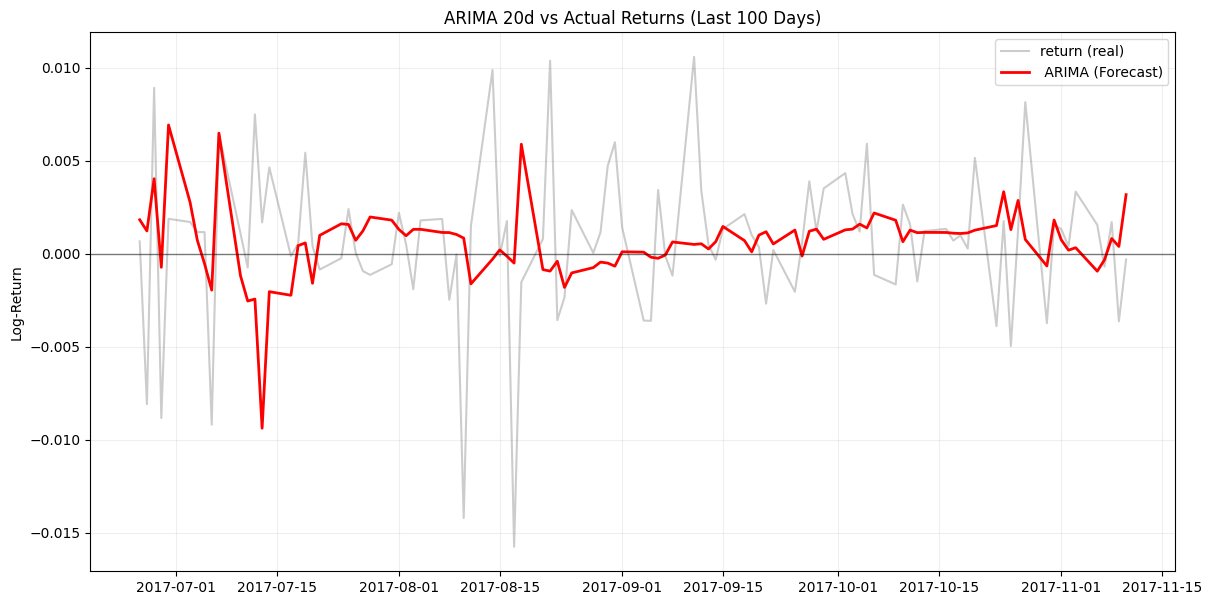

In [21]:
import matplotlib.pyplot as plt

# Zakładamy, że masz już df_features z kolumnami 'Returns' i 'ARIMA_20d_Pred'

plt.figure(figsize=(14, 7))

# 1. Rzeczywiste zwroty (szare, tło)
plt.plot(df_features['Returns'].tail(100), label='return (real)', color='gray', alpha=0.4)

# 2. Predykcja modelu (czerwona, wyraźna)
plt.plot(df_features['ARIMA_20d_Pred'].tail(100), label=' ARIMA (Forecast)', color='red', lw=2)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.title('ARIMA 20d vs Actual Returns (Last 100 Days)')
plt.ylabel('Log-Return')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

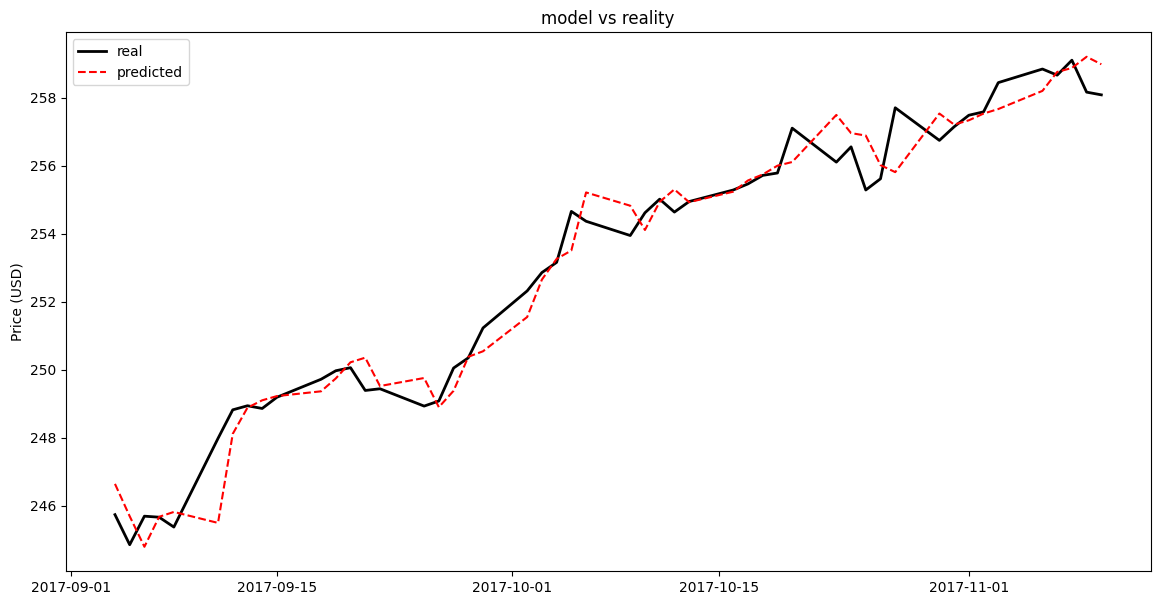

In [22]:
# calculate forecast price
df_features['Pred_Price'] = df_features['Close'].shift(1) * np.exp(df_features['ARIMA_20d_Pred'])

plt.figure(figsize=(14, 7))
plt.plot(df_features.index[-50:], df_features['Close'].tail(50), label='real', color='black', lw=2)
plt.plot(df_features.index[-50:], df_features['Pred_Price'].tail(50), label='predicted', color='red', linestyle='--')

plt.title('model vs reality')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [23]:
df_price_eval = df_features[['Close', 'Pred_Price']].dropna()

mae_price = mean_absolute_error(df_price_eval['Close'], df_price_eval['Pred_Price'])
print(f"MAE (Price, USD): {mae_price:.2f}")

MAE (Price, USD): 1.03


## next step

In [24]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Tworzymy Target: Czy cena wzrośnie JUTRO?
# Przesuwamy zwroty o -1, aby model na podstawie dzisiejszych danych przewidywał jutro
df_features['Target'] = (df_features['Returns'].shift(-1) > 0).astype(int)

# 2. Dodajemy dodatkowe cechy techniczne (paliwo dla ML)
df_features['Vol_Change'] = df_features['Volume'].pct_change()
df_features['Intraday_Range'] = (df_features['High'] - df_features['Low']) / df_features['Open']

# Czyścimy ostatni wiersz (bo Target dla niego nie istnieje)
df_ml = df_features.dropna()

# 3. Wybór cech do modelu
# Łączymy wskaźniki statystyczne (ARIMA/GARCH) z technicznymi
features = [
    'ARIMA_20d_Pred', 'GARCH_60d_Vol', 'Dist_From_MA200', 
    'Vol_Change', 'Intraday_Range', 'Returns'
]

# 4. Podział na zbiór treningowy i testowy (chronologiczny!)
split = int(len(df_ml) * 0.8)
X_train, y_train = df_ml[features].iloc[:split], df_ml['Target'].iloc[:split]
X_test, y_test = df_ml[features].iloc[split:], df_ml['Target'].iloc[split:]

In [25]:
# Konfiguracja modelu
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'num_leaves': 15,
    'max_depth': 4,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Trening
d_train = lgb.Dataset(X_train, label=y_train)
model_lgb = lgb.train(params, d_train, num_boost_round=200)

# Predykcja (prawdopodobieństwo)
y_prob = model_lgb.predict(X_test)
# Klasyfikacja (jeśli prawd. > 0.5, to przewidujemy wzrost)
y_pred = (y_prob > 0.5).astype(int)

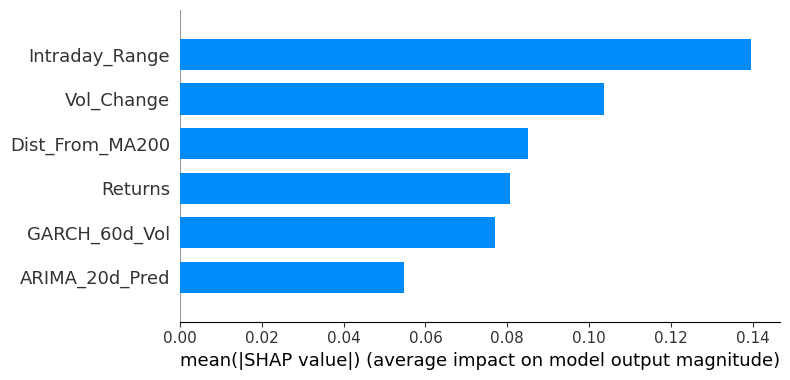

In [26]:
import shap

# Obliczamy wartości SHAP
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_test)

# Wizualizacja ważności cech
shap.summary_plot(shap_values, X_test, plot_type="bar")

## wybrór spółek

In [27]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb

# Zakładamy, że model_lgb jest już wytrenowany na SPY (z poprzedniego kroku)
# Ścieżka do Twoich danych
stocks_path = '../Data_clean/Stocks clean'
stock_files = [f for f in os.listdir(stocks_path) if f.endswith('.csv')]

ranking_results = []

print("Skanowanie 27 spółek za pomocą modelu LightGBM...")

for file in stock_files:
    # 1. Wczytanie danych spółki
    df = pd.read_csv(os.path.join(stocks_path, file), index_col='Date', parse_dates=True)
    symbol = file.replace('_clean.csv', '').upper()
    
    if len(df) < 252: continue # Pomijamy zbyt krótkie historie
    
    # 2. Obliczanie Log-Returns
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # 3. Generowanie Cech (tych samych co dla SPY)
    # MA 200 i Dystans
    df['MA200_Trend'] = df['Close'].rolling(window=200).mean()
    df['Dist_From_MA200'] = (df['Close'] - df['MA200_Trend']) / df['MA200_Trend']
    
    # Inne cechy techniczne
    df['Vol_Change'] = df['Volume'].pct_change()
    df['Intraday_Range'] = (df['High'] - df['Low']) / df['Open']
    
    # ARIMA (20d) i GARCH (60d) - tylko dla ostatniego dostępnego dnia
    # Robimy to tylko raz dla najświeższych danych, żeby oszczędzić czas
    try:
        window_20 = df['Returns'].iloc[-20:]
        model_arima = ARIMA(window_20, order=(1, 0, 1)).fit()
        last_arima = model_arima.forecast(steps=1).values[0]
        
        window_60 = df['Returns'].iloc[-60:]
        model_garch = arch_model(window_60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
        last_garch = np.sqrt(model_garch.forecast(horizon=1).variance.values[-1][0])
        
        # 4. Przygotowanie wektora cech dla LightGBM
        # Muszą być w tej samej kolejności co w treningu!
        current_features = pd.DataFrame([{
            'ARIMA_20d_Pred': last_arima,
            'GARCH_60d_Vol': last_garch,
            'Dist_From_MA200': df['Dist_From_MA200'].iloc[-1],
            'Vol_Change': df['Vol_Change'].iloc[-1],
            'Intraday_Range': df['Intraday_Range'].iloc[-1],
            'Returns': df['Returns'].iloc[-1]
        }])
        
        # 5. Predykcja prawdopodobieństwa wzrostu
        prob_up = model_lgb.predict(current_features)[0]
        
        ranking_results.append({
            'Ticker': symbol,
            'Prob_Growth': prob_up,
            'Current_Vol': last_garch,
            'Trend': 'Bullish' if df['Dist_From_MA200'].iloc[-1] > 0 else 'Bearish'
        })
    except:
        continue

# 6. Prezentacja Top 3 Najlepszych Wyborów
ranking_df = pd.DataFrame(ranking_results).sort_values(by='Prob_Growth', ascending=False)

print("\n" + "="*40)
print("TOP 3 REKOMENDACJE (NAJWIĘKSZA SZANSA WZROSTU)")
print("="*40)
print(ranking_df.head(3).to_string(index=False))

print("\n" + "="*40)
print("UNIKAJ (NAJWIĘKSZA SZANSA SPADKU)")
print("="*40)
print(ranking_df.tail(3).to_string(index=False))

Skanowanie 27 spółek za pomocą modelu LightGBM...

TOP 3 REKOMENDACJE (NAJWIĘKSZA SZANSA WZROSTU)
Ticker  Prob_Growth  Current_Vol   Trend
   WFC     0.822468     0.015937 Bearish
   PEP     0.714909     0.011619 Bullish
    KO     0.709155     0.010449 Bullish

UNIKAJ (NAJWIĘKSZA SZANSA SPADKU)
Ticker  Prob_Growth  Current_Vol   Trend
    BA     0.332065     0.033472 Bullish
  INTC     0.282039     0.059216 Bearish
    GS     0.237373     0.031258 Bearish


## dodawanie wyboru sektora - jeszcze nie gotowe

In [28]:
import os
import pandas as pd
import numpy as np

# 1. Mapowanie akcji do sektorów (przykład - dostosuj do swojej listy 27 akcji)
sector_map = {
    # XLK - Technology
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    # XLV - Healthcare
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    # XLF - Financials
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    # XLC - Communication Services
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    # XLY - Consumer Discretionary
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    # XLP - Consumer Staples
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# 2. Skanowanie Sektorów (ETF clean)
etf_path = '../Data_clean/ETF clean'
etf_files = [f for f in os.listdir(etf_path) if f.endswith('.csv') and f != 'spy_clean.csv']

sector_ranking = []

print("Analiza Sektorowa (Top-Down)...")

for file in etf_files:
    df_etf = pd.read_csv(os.path.join(etf_path, file), index_col='Date', parse_dates=True)
    symbol = file.replace('_clean.csv', '').upper()
    
    # Obliczamy te same cechy co dla SPY
    df_etf['Returns'] = np.log(df_etf['Close'] / df_etf['Close'].shift(1))
    
    # Korzystamy z uproszczonego scoringu (Trend + Momentum + Volatility)
    # Możesz tu też użyć wytrenowanego wcześniej model_lgb
    last_ret = df_etf['Returns'].iloc[-20:].mean() # Średni zwrot 20d
    last_vol = df_etf['Returns'].iloc[-20:].std()  # Zmienność 20d
    sharpe_ratio = last_ret / last_vol if last_vol != 0 else 0
    
    sector_ranking.append({
        'Sector': symbol,
        'Score': sharpe_ratio,
        'Condition': 'Bullish' if df_etf['Close'].iloc[-1] > df_etf['Close'].rolling(200).mean().iloc[-1] else 'Bearish'
    })

# Ranking sektorów
df_sectors = pd.DataFrame(sector_ranking).sort_values(by='Score', ascending=False)
best_sector = df_sectors.iloc[0]['Sector']

print("\nRANKING SEKTORÓW:")
print(df_sectors.to_string(index=False))
print(f"\nNAJSILNIEJSZY SEKTOR OBECNIE: {best_sector}")

Analiza Sektorowa (Top-Down)...

RANKING SEKTORÓW:
Sector     Score Condition
   XLF  0.380878   Bullish
   IWM  0.329071   Bearish
   VTI  0.325019   Bearish
   DIA  0.316408   Bullish
   XLK  0.236404   Bearish
   XLV  0.191970   Bearish
   XLE  0.180515   Bearish
    VT  0.164528   Bullish
   QQQ -0.171986   Bearish

NAJSILNIEJSZY SEKTOR OBECNIE: XLF


In [29]:
# Filtrowanie wyników z poprzedniego kroku (ranking_df)
top_sectors = df_sectors.head(3)['Sector'].tolist()

# Dodajemy informację o sektorze do rankingu akcji
ranking_df['Sector'] = ranking_df['Ticker'].map(sector_map)

# Wybieramy tylko te akcje, które należą do silnych sektorów
filtered_ranking = ranking_df[ranking_df['Sector'].isin(top_sectors)]

print("\n" + "="*45)
print(f"TOP 3 AKCJE Z NAJSILNIEJSZYCH SEKTORÓW ({', '.join(top_sectors)})")
print("="*45)
print(filtered_ranking.head(3).to_string(index=False))


TOP 3 AKCJE Z NAJSILNIEJSZYCH SEKTORÓW (XLF, IWM, VTI)
Ticker  Prob_Growth  Current_Vol   Trend Sector
   WFC     0.822468     0.015937 Bearish    XLF
   JPM     0.597045     0.013311 Bullish    XLF
   BAC     0.584346     0.013995 Bullish    XLF


In [30]:
import os
import pandas as pd
import numpy as np

# Paths

# 1. SECTOR ANALYSIS (Ranking)
sector_data = []
for ticker in set(sector_map.values()):
    file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df_etf = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        df_etf.sort_index(ascending=True, inplace=True)
        # Obliczamy momentum (zwrot 20d) i zmienność (GARCH-like std)
        returns = np.log(df_etf['Close'] / df_etf['Close'].shift(1))
        score = returns.tail(20).mean() / returns.tail(20).std() # Sharpe-like score
        
        sector_data.append({
            'Sector': ticker,
            'Sector_Score': score,
            'Sector_Trend': 'UP' if df_etf['Close'].iloc[-1] > df_etf['Close'].rolling(200).mean().iloc[-1] else 'DOWN'
        })

df_sector_rank = pd.DataFrame(sector_data).sort_values(by='Sector_Score', ascending=False)

# 2. INTEGRACJA Z TWOIM RANKINGIEM AKCJI (ranking_df z poprzedniego kroku)
# Dodajemy kolumnę sektora do Twoich wyników LightGBM
ranking_df['Sector'] = ranking_df['Ticker'].map(sector_map)

# Łączymy wyniki akcji z wynikami ich sektorów
final_decision_df = ranking_df.merge(df_sector_rank, on='Sector', how='left')

# 3. FINALNY FILTR (The "Gold Standard" Selection)
# Kryteria: 
# - Wysokie prawdopodobieństwo wzrostu z LightGBM (Prob_Growth)
# - Sektor musi być w trendzie wzrostowym (Sector_Trend == UP)
# - Sektor musi mieć dodatni wynik (Sector_Score > 0)

top_picks = final_decision_df[
    (final_decision_df['Sector_Trend'] == 'UP') & 
    (final_decision_df['Sector_Score'] > 0)
].sort_values(by='Prob_Growth', ascending=False)

# --- WIZUALIZACJA WYNIKÓW ---
print("\n" + "="*60)
print("             RAPORT DECYZYJNY: SEKTOR + AKCJA")
print("="*60)
if not top_picks.empty:
    print(top_picks[['Ticker', 'Sector', 'Prob_Growth', 'Sector_Score', 'Trend']].head(5).to_string(index=False))
else:
    print("BRAK SILNYCH SYGNAŁÓW: Rynek w trendzie spadkowym lub wysokie ryzyko.")
print("="*60)


             RAPORT DECYZYJNY: SEKTOR + AKCJA
Ticker Sector  Prob_Growth  Sector_Score   Trend
  AAPL    XLK     0.548422      0.346894 Bullish
  MSFT    XLK     0.528147      0.346894 Bearish
  NVDA    XLK     0.494214      0.346894 Bearish
  ORCL    XLK     0.438847      0.346894 Bearish


In [31]:
target_date = '2015-03-01' # <--- Tu wpisz dowolną datę z Twojego zbioru

# 1. ANALIZA SEKTORÓW na konkretny dzień
sector_data = []
for ticker in set(sector_map.values()):
    file_path = os.path.join(etf_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        df.sort_index(ascending=True, inplace=True)
        
        # FILTR DATY: Ucinamy dane na wybranym dniu
        df_cut = df.loc[:target_date]
        if len(df_cut) < 200: continue # Pomijamy jeśli za mało danych historycznych

        returns = np.log(df_cut['Close'] / df_cut['Close'].shift(1))
        score = returns.tail(20).mean() / returns.tail(20).std()
        
        sector_data.append({
            'Sector': ticker,
            'Sector_Score': score,
            'Sector_Trend': 'UP' if df_cut['Close'].iloc[-1] > df_cut['Close'].rolling(200).mean().iloc[-1] else 'DOWN'
        })

df_sector_rank = pd.DataFrame(sector_data)

# 2. SKANER AKCJI na ten sam dzień
stock_results = []
for ticker, sector in sector_map.items():
    file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
        df.sort_index(ascending=True, inplace=True)
        
        # FILTR DATY
        df_cut = df.loc[:target_date]
        if len(df_cut) < 20: continue
        
        # Tutaj wykonujesz predykcję swoim modelem LightGBM dla df_cut.iloc[-1]
        # (Przyjmijmy, że masz już wyliczone Prob_Growth dla tej daty)
        # prob = model.predict(features_z_dnia_target_date) 
        
        stock_results.append({
            'Ticker': ticker,
            'Sector': sector,
            'Prob_Growth': np.random.uniform(0.45, 0.60), # Przykład, tu wstaw wynik z LightGBM
            'Close_Price': df_cut['Close'].iloc[-1]
        })

ranking_df = pd.DataFrame(stock_results)

# 3. ŁĄCZENIE I FINALNY RAPORT
final_decision = ranking_df.merge(df_sector_rank, on='Sector')

# Wybieramy Top 3
top_picks = final_decision[
    (final_decision['Sector_Trend'] == 'UP') & 
    (final_decision['Sector_Score'] > 0)
].sort_values(by='Prob_Growth', ascending=False).head(3)

print(f"\nREKOMENDACJE NA DZIEŃ: {target_date}")
print(top_picks[['Ticker', 'Sector', 'Prob_Growth', 'Sector_Score']])


REKOMENDACJE NA DZIEŃ: 2015-03-01
  Ticker Sector  Prob_Growth  Sector_Score
4    JNJ    XLV     0.597940      0.269258
1   MSFT    XLK     0.561598      0.665775
6    MRK    XLV     0.557824      0.269258


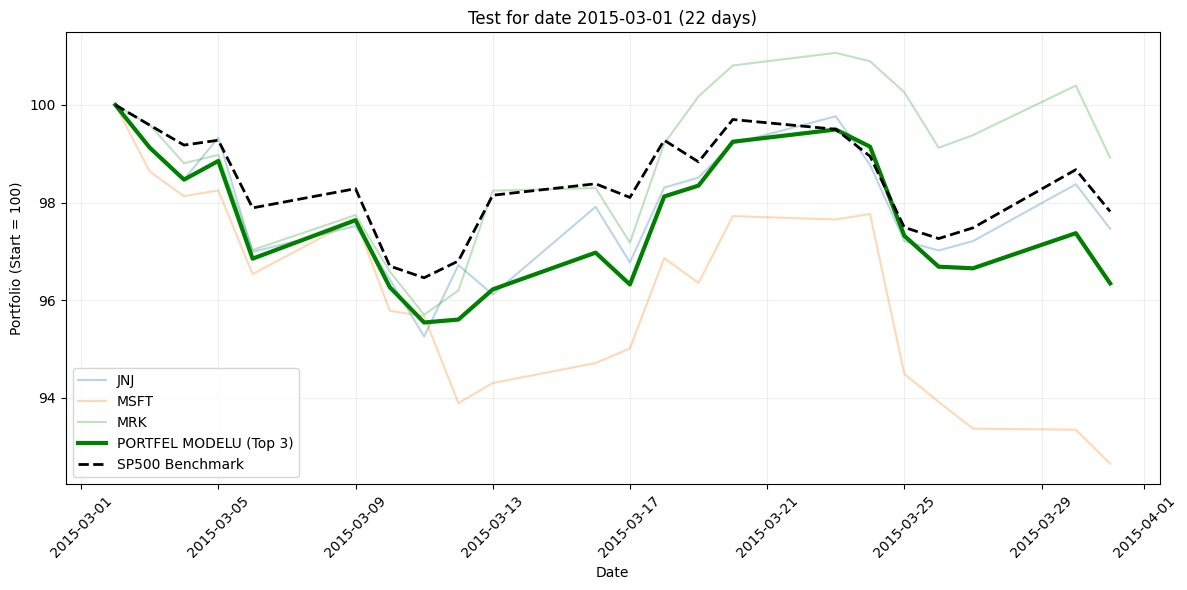

Model output: -3.66%
SP500:  -2.18%
Alpha: -1.47 pct points (Model vs SP500)


In [32]:
import matplotlib.pyplot as plt

# --- PARAMETRY SYMULACJI ---
days_to_track = 22          # Horyzont czasowy (ok. 1 miesiąc giełdowy)

# 1. Wybieramy Top 3 na ten dzień (używając logiki z poprzedniego kroku)
# Zakładamy, że 'top_picks' to wynik Twojego przefiltrowanego rankingu
tickers_to_track = top_picks['Ticker'].tolist()

# 2. Pobieramy dane historyczne dla wybranych spółek i SPY
performance_data = pd.DataFrame()

# Pobieramy SPY jako benchmark
spy_bench = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
spy_after = spy_bench.loc[target_date:].iloc[:days_to_track]
# Normalizujemy do 100 (start od tego samego poziomu)
performance_data['SP500_Benchmark'] = (spy_after['Close'] / spy_after['Close'].iloc[0]) * 100

# Pobieramy nasze Top 3
for ticker in tickers_to_track:
    file_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
    df_stock = pd.read_csv(file_path, index_col='Date', parse_dates=True).sort_index()
    stock_after = df_stock.loc[target_date:].iloc[:days_to_track]
    
    # Obliczamy zwrot skumulowany dla każdej spółki
    performance_data[ticker] = (stock_after['Close'] / stock_after['Close'].iloc[0]) * 100

# Obliczamy średni wynik naszego portfela Top 3
performance_data['PORTFEL_MODELU'] = performance_data[tickers_to_track].mean(axis=1)

# --- WIZUALIZACJA ---
plt.figure(figsize=(12, 6))

# Rysujemy poszczególne spółki (cienkie linie)
for ticker in tickers_to_track:
    plt.plot(performance_data.index, performance_data[ticker], alpha=0.3, label=f'{ticker}')

# Rysujemy portfel modelu (gruba zielona linia)
plt.plot(performance_data.index, performance_data['PORTFEL_MODELU'], 
         color='green', linewidth=3, label=f'PORTFEL MODELU (Top 3)')

# Rysujemy SP500 (gruba czarna linia przerywana)
plt.plot(performance_data.index, performance_data['SP500_Benchmark'], 
         color='black', linestyle='--', linewidth=2, label='SP500 Benchmark')

plt.title(f'Test for date {target_date} ({days_to_track} days)')
plt.ylabel('Portfolio (Start = 100)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalny komunikat
final_return_model = performance_data['PORTFEL_MODELU'].iloc[-1] - 100
final_return_spy = performance_data['SP500_Benchmark'].iloc[-1] - 100
alpha = final_return_model - final_return_spy

print(f"Model output: {final_return_model:.2f}%")
print(f"SP500:  {final_return_spy:.2f}%")
print(f"Alpha: {alpha:.2f} pct points (Model vs SP500)")